# 04 — LIME / XAI for Hyperspectral Ensemble (15-Channel)

## What this notebook does:
- Loads trained models from Notebook 03 (ResNet50, DenseNet121, CustomCNN)
- Applies **LIME** (Local Interpretable Model-agnostic Explanations) to hyperspectral images
- Key challenge: LIME expects 3-channel RGB → we solve this with a 15-channel wrapper
- Generates publication-quality visualizations

## Visualizations included:
1. Single sample LIME explanation (4-panel)
2. Multi-class LIME grid (one per class)
3. Per-model LIME comparison
4. PCA band importance via occlusion
5. Heatmap overlay on pseudo-RGB
6. Confidence + explanation dashboard

---
**Models expected from Notebook 03:**
- `../models/ResNet50_final.h5`
- `../models/DenseNet121_final.h5`
- `../models/CustomCNN_final.h5`
- `../models/hyper_label_encoder.pkl`


In [1]:
# ─── Cell 1: Imports ───────────────────────────────────────────────────────────
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import losses

from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb
from sklearn.metrics import classification_report

# Install if needed:
# pip install lime scikit-image

print(f'TensorFlow : {tf.__version__}')
print(f'LIME       : imported OK')
print(f'NumPy      : {np.__version__}')


TensorFlow : 2.19.1
LIME       : imported OK
NumPy      : 2.1.3


In [2]:
# ─── Cell 2: Config & Paths ────────────────────────────────────────────────────
PROCESSED_DIR = '../data/processed/'
MODEL_DIR     = '../models/'
OUTPUT_DIR    = '../models/lime_outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model paths — match what Notebook 03 saved
CNN_PATH     = os.path.join(MODEL_DIR, 'CustomCNN_final.h5')
RESNET_PATH  = os.path.join(MODEL_DIR, 'ResNet50_final.h5')
DENSE_PATH   = os.path.join(MODEL_DIR, 'DenseNet121_final.h5')
ENCODER_PATH = os.path.join(MODEL_DIR, 'hyper_label_encoder.pkl')

CLASS_NAMES  = ['Healthy (0.0)', 'Partial (0.5)', 'Deficient (1.0)']
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']   # Green, Orange, Red
N_CLASSES    = 3
IMG_H, IMG_W = 128, 128
N_BANDS      = 15

# Ensemble weights from Notebook 03 (or load from file if saved)
ENSEMBLE_WEIGHTS = np.array([0.33, 0.33, 0.34])  # [CustomCNN, ResNet50, DenseNet121]

print('Config set.')
print(f'Output directory: {OUTPUT_DIR}')


Config set.
Output directory: ../models/lime_outputs/


In [6]:
# ─── Cell 3: Load Data & Models (FIXED v2) ────────────────────────────────────
#
# Error 1 (fixed previously): focal_loss — solved with compile=False
# Error 2 (this fix): Lambda layer stores 'preprocess_input' as a named function.
# Keras 3.x cannot locate it during deserialization unless we pass it explicitly
# via custom_objects. Solution: pass both resnet & densenet preprocess_input.
#

print('Loading test data (15-channel hyperspectral)...')
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test_hyper.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test_hyper.npy'))

with open(ENCODER_PATH, 'rb') as f:
    le = pickle.load(f)
y_test_enc = le.transform(y_test)

assert X_test.shape[-1] == N_BANDS, f'Expected {N_BANDS} channels, got {X_test.shape[-1]}'
print(f'X_test shape : {X_test.shape}')
print(f'Classes      : {le.classes_}')

# ── Import both preprocess_input functions used in Notebook 03 ──
from tensorflow.keras.applications.resnet50  import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

# ── custom_objects tells Keras where to find the Lambda functions ──
CUSTOM_OBJ = {
    'preprocess_input': resnet_preprocess,   # covers ResNet50 Lambda layer
}
CUSTOM_OBJ_DENSE = {
    'preprocess_input': dense_preprocess,    # covers DenseNet121 Lambda layer
}

def safe_load_model(path, custom_objects=None):
    """
    Load .h5 model saved with focal_loss + Lambda(preprocess_input).
    compile=False  → skips focal_loss deserialization error
    custom_objects → tells Keras which function 'preprocess_input' maps to
    """
    model = load_model(path, compile=False, custom_objects=custom_objects)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print('\nLoading models...')
cnn_model      = safe_load_model(CNN_PATH)                          # CustomCNN — no Lambda layer
resnet_model   = safe_load_model(RESNET_PATH,  CUSTOM_OBJ)         # ResNet50  — has Lambda(resnet_preprocess)
densenet_model = safe_load_model(DENSE_PATH,   CUSTOM_OBJ_DENSE)   # DenseNet  — has Lambda(dense_preprocess)

all_models  = [cnn_model, resnet_model, densenet_model]
model_names = ['CustomCNN', 'ResNet50', 'DenseNet121']

print(f'Models loaded : {model_names}')
print(f'Ensemble wts  : {ENSEMBLE_WEIGHTS}')
print('\n✅ All models loaded successfully!')

Loading test data (15-channel hyperspectral)...
X_test shape : (318, 128, 128, 15)
Classes      : [0 1 2]

Loading models...

Models loaded : ['CustomCNN', 'ResNet50', 'DenseNet121']
Ensemble wts  : [0.33 0.33 0.34]

✅ All models loaded successfully!


In [7]:
# ─── Cell 4: Core LIME Utility Functions ──────────────────────────────────────
#
# KEY PROBLEM: LIME works with 3-channel RGB images internally.
# Our images are 15-channel (PCA components).
#
# SOLUTION:
# 1. Convert 15ch → 3ch pseudo-RGB (using first 3 PCA bands) for LIME display
# 2. When LIME perturbs the 3ch image, reconstruct the 15ch version
#    by applying the same spatial mask across all 15 channels
# 3. Feed 15ch reconstructed image to ensemble

def hsi_to_pseudoRGB(hsi_15ch):
    """
    Convert (H, W, 15) hyperspectral image to (H, W, 3) pseudo-RGB.
    Uses PCA components 0, 1, 2 — they carry the most spectral variance.
    Output is float32 normalized to [0, 1].
    """
    rgb = hsi_15ch[:, :, :3].copy().astype(np.float32)
    for c in range(3):
        ch = rgb[:, :, c]
        vmin, vmax = ch.min(), ch.max()
        if vmax > vmin:
            rgb[:, :, c] = (ch - vmin) / (vmax - vmin)
        else:
            rgb[:, :, c] = 0.0
    return rgb


def ensemble_predict_15ch(batch_15ch):
    """
    Run all 3 models on a (N, 128, 128, 15) batch.
    Returns weighted ensemble probability array (N, 3).
    """
    preds = [m.predict(batch_15ch, batch_size=32, verbose=0) for m in all_models]
    return np.average(preds, axis=0, weights=ENSEMBLE_WEIGHTS)


def make_lime_predict_fn(original_15ch):
    """
    Build a LIME-compatible predict function for one 15-channel sample.

    LIME calls this with (N, H, W, 3) perturbed pseudo-RGB images.
    For each perturbed image:
      - Detect which pixels were masked by LIME (large diff from original pseudo-RGB)
      - Apply same mask spatially across all 15 channels
      - Run ensemble on reconstructed 15ch images
    """
    pseudo_rgb_orig = hsi_to_pseudoRGB(original_15ch)   # (H, W, 3)

    def predict_fn(perturbed_3ch_batch):
        N = len(perturbed_3ch_batch)
        batch_15ch = np.zeros((N, IMG_H, IMG_W, N_BANDS), dtype=np.float32)

        for i, img_3ch in enumerate(perturbed_3ch_batch):
            # Find pixels LIME has masked (set to grey/black hide_color)
            diff        = np.abs(img_3ch.astype(np.float32) - pseudo_rgb_orig).mean(axis=-1)
            masked_pix  = diff > 0.08   # pixels with diff > threshold = masked by LIME

            # Apply same mask to all 15 bands
            reconstructed                = original_15ch.copy()
            reconstructed[masked_pix]    = 0.0
            batch_15ch[i]               = reconstructed

        return ensemble_predict_15ch(batch_15ch)

    return predict_fn


def predict_single(hsi_15ch):
    """Run ensemble on one (128,128,15) image. Returns (probs, pred_idx, confidence)."""
    batch  = hsi_15ch[np.newaxis]   # (1, 128, 128, 15)
    probs  = ensemble_predict_15ch(batch)[0]
    pidx   = int(np.argmax(probs))
    return probs, pidx, float(probs[pidx])


print('LIME utility functions defined.')
print('  hsi_to_pseudoRGB()     - 15ch -> 3ch display image')
print('  make_lime_predict_fn() - wraps ensemble for LIME')
print('  predict_single()       - ensemble predict for one image')


LIME utility functions defined.
  hsi_to_pseudoRGB()     - 15ch -> 3ch display image
  make_lime_predict_fn() - wraps ensemble for LIME
  predict_single()       - ensemble predict for one image


In [8]:
# ─── Cell 5: LIME on a Single Sample ──────────────────────────────────────────
IMAGE_INDEX = 5     # Change to explore different samples
NUM_SAMPLES = 1000  # Increase to 2000 for paper-quality results (slower)

sample_15ch   = X_test[IMAGE_INDEX]           # (128, 128, 15)
true_label    = CLASS_NAMES[y_test_enc[IMAGE_INDEX]]
pseudo_rgb    = hsi_to_pseudoRGB(sample_15ch)  # (128, 128, 3)

probs, pred_idx, confidence = predict_single(sample_15ch)
pred_label    = CLASS_NAMES[pred_idx]
correct       = pred_idx == y_test_enc[IMAGE_INDEX]

print(f'Sample index    : {IMAGE_INDEX}')
print(f'True label      : {true_label}')
print(f'Predicted       : {pred_label}  ({confidence*100:.1f}% confidence)')
print(f'Correct         : {correct}')
print(f'All probs       : { {c: f"{p:.3f}" for c, p in zip(CLASS_NAMES, probs)} }')

# Run LIME
print(f'\nRunning LIME with {NUM_SAMPLES} samples... (takes ~1-2 min)')
lime_predict_fn = make_lime_predict_fn(sample_15ch)
explainer       = lime_image.LimeImageExplainer(random_state=42)

explanation = explainer.explain_instance(
    image         = pseudo_rgb,
    classifier_fn = lime_predict_fn,
    top_labels    = N_CLASSES,
    hide_color    = 0,
    num_samples   = NUM_SAMPLES,
    batch_size    = 32
)
print('LIME explanation complete!')


Sample index    : 5
True label      : Deficient (1.0)
Predicted       : Deficient (1.0)  (68.4% confidence)
Correct         : True
All probs       : {'Healthy (0.0)': '0.142', 'Partial (0.5)': '0.174', 'Deficient (1.0)': '0.684'}

Running LIME with 1000 samples... (takes ~1-2 min)


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation complete!


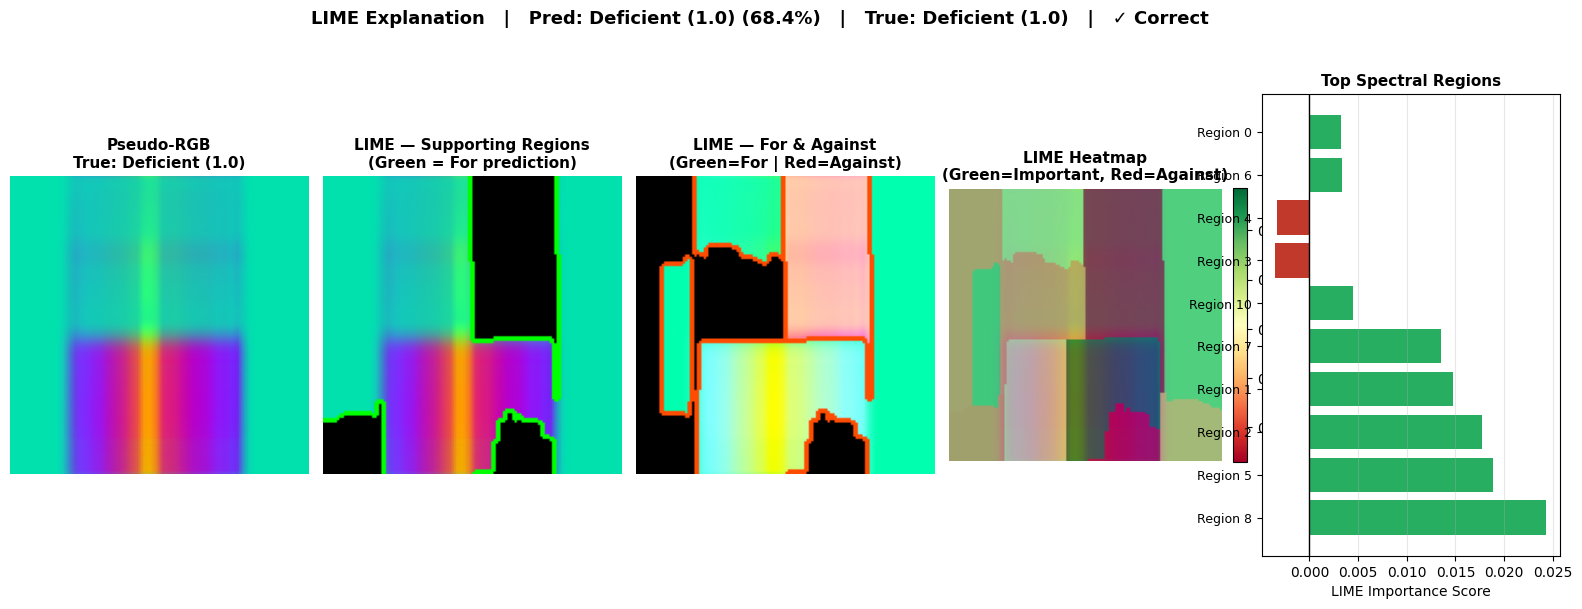

Saved: lime_single_sample_5.png


In [9]:
# ─── Cell 6: Visualization 1 — 4-Panel Single Sample LIME ─────────────────────
fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.05)

title_color = CLASS_COLORS[pred_idx]

# Panel 1: Original pseudo-RGB
ax1 = fig.add_subplot(gs[0])
ax1.imshow(pseudo_rgb)
ax1.set_title(f'Pseudo-RGB\nTrue: {true_label}', fontweight='bold', fontsize=11)
ax1.axis('off')
for spine in ax1.spines.values(): spine.set_edgecolor('#34495e'); spine.set_linewidth(2)

# Panel 2: LIME — only supporting (positive) regions
temp_pos, mask_pos = explanation.get_image_and_mask(
    pred_idx, positive_only=True, num_features=8, hide_rest=True
)
ax2 = fig.add_subplot(gs[1])
ax2.imshow(mark_boundaries(temp_pos, mask_pos, color=(0, 1, 0), mode='thick'))
ax2.set_title('LIME — Supporting Regions\n(Green = For prediction)', fontweight='bold', fontsize=11)
ax2.axis('off')

# Panel 3: LIME — all regions, rest hidden
temp_all, mask_all = explanation.get_image_and_mask(
    pred_idx, positive_only=False, num_features=8, hide_rest=True
)
ax3 = fig.add_subplot(gs[2])
ax3.imshow(mark_boundaries(temp_all, mask_all, color=(1, 0.3, 0), mode='thick'))
ax3.set_title('LIME — For & Against\n(Green=For | Red=Against)', fontweight='bold', fontsize=11)
ax3.axis('off')

# Panel 4: LIME heatmap (continuous importance map)
ax4 = fig.add_subplot(gs[3])
ind  = explanation.top_labels[0]
dict_heatmap = dict(explanation.local_exp[ind])
heatmap = np.vectorize(dict_heatmap.get)(explanation.segments)
im = ax4.imshow(heatmap, cmap='RdYlGn', vmin=heatmap.min(), vmax=heatmap.max())
ax4.imshow(pseudo_rgb, alpha=0.35)   # Overlay original for context
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('LIME Heatmap\n(Green=Important, Red=Against)', fontweight='bold', fontsize=11)
ax4.axis('off')

# Panel 5: Feature importance bar chart
ax5 = fig.add_subplot(gs[4])
vals = explanation.local_exp[pred_idx]
vals_sorted = sorted(vals, key=lambda x: abs(x[1]), reverse=True)[:10]
feat_ids, importances = zip(*vals_sorted)
colors_bar = ['#27ae60' if v > 0 else '#c0392b' for v in importances]
ax5.barh(range(len(feat_ids)), importances, color=colors_bar)
ax5.set_yticks(range(len(feat_ids)))
ax5.set_yticklabels([f'Region {f}' for f in feat_ids], fontsize=9)
ax5.set_xlabel('LIME Importance Score', fontsize=10)
ax5.set_title('Top Spectral Regions', fontweight='bold', fontsize=11)
ax5.axvline(x=0, color='black', linewidth=1)
ax5.grid(axis='x', alpha=0.3)

status = '✓ Correct' if correct else '✗ Wrong'
fig.suptitle(
    f'LIME Explanation   |   Pred: {pred_label} ({confidence*100:.1f}%)   |   True: {true_label}   |   {status}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.savefig(os.path.join(OUTPUT_DIR, f'lime_single_sample_{IMAGE_INDEX}.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: lime_single_sample_{IMAGE_INDEX}.png')


Finding correctly predicted samples for each class...
Sample indices chosen: {0: np.int64(6), 1: np.int64(92), 2: np.int64(4)}

  LIME for Healthy (0.0) (index 6) — predicted: Healthy (0.0) (55.9%)


  0%|          | 0/800 [00:00<?, ?it/s]

  LIME done.

  LIME for Partial (0.5) (index 92) — predicted: Partial (0.5) (37.0%)


  0%|          | 0/800 [00:00<?, ?it/s]

  LIME done.

  LIME for Deficient (1.0) (index 4) — predicted: Deficient (1.0) (58.9%)


  0%|          | 0/800 [00:00<?, ?it/s]

  LIME done.


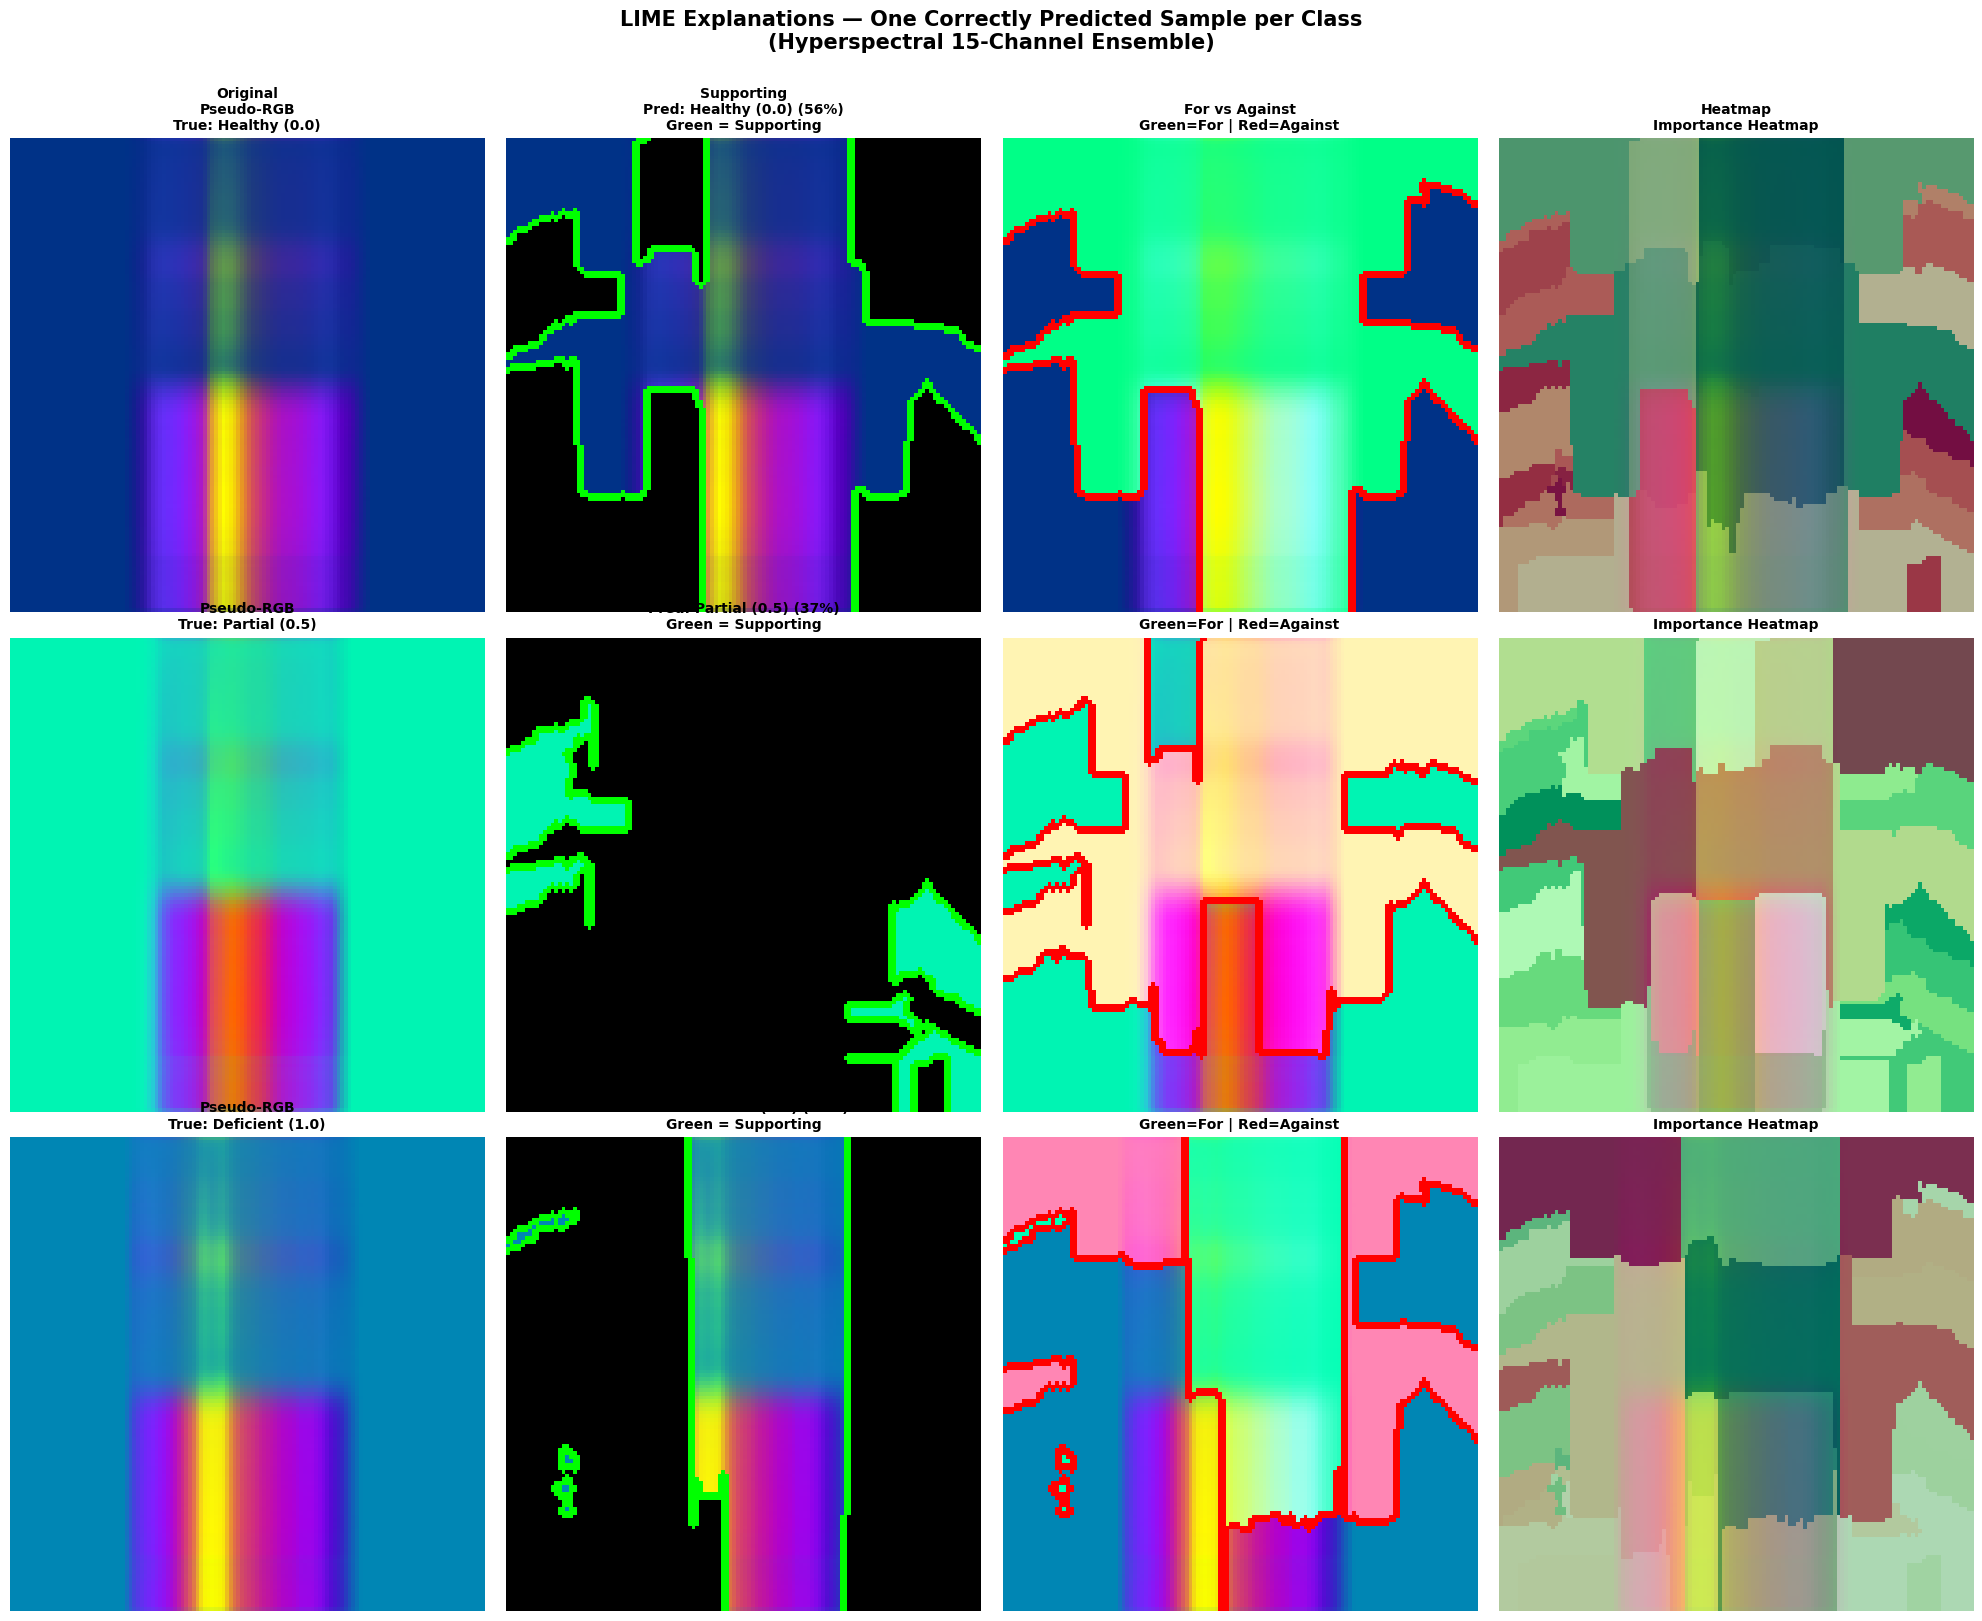


Saved: lime_all_classes_grid.png


In [10]:
# ─── Cell 7: Visualization 2 — LIME for All 3 Classes (Research Grid) ─────────
# Find one correctly-predicted sample per class

print('Finding correctly predicted samples for each class...')

class_samples = {}
all_preds_full = np.argmax(ensemble_predict_15ch(X_test), axis=1)

for cls_idx in range(N_CLASSES):
    candidates = np.where((y_test_enc == cls_idx) & (all_preds_full == cls_idx))[0]
    if len(candidates) == 0:
        candidates = np.where(y_test_enc == cls_idx)[0]  # fallback: any sample
    class_samples[cls_idx] = candidates[2]  # Use 3rd sample (more representative)

print(f'Sample indices chosen: {class_samples}')

# Run LIME for each class
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
fig.suptitle(
    'LIME Explanations — One Correctly Predicted Sample per Class\n'
    '(Hyperspectral 15-Channel Ensemble)',
    fontsize=15, fontweight='bold', y=1.01
)

for row, (cls_idx, img_idx) in enumerate(class_samples.items()):
    sample = X_test[img_idx]
    rgb_i  = hsi_to_pseudoRGB(sample)
    true_l = CLASS_NAMES[cls_idx]

    probs_i, pidx_i, conf_i = predict_single(sample)
    pred_l = CLASS_NAMES[pidx_i]

    print(f'\n  LIME for {true_l} (index {img_idx}) — predicted: {pred_l} ({conf_i*100:.1f}%)')
    lime_fn_i = make_lime_predict_fn(sample)
    exp_i = explainer.explain_instance(
        image=rgb_i, classifier_fn=lime_fn_i,
        top_labels=N_CLASSES, hide_color=0,
        num_samples=800, batch_size=32
    )
    print(f'  LIME done.')

    axes[row, 0].imshow(rgb_i)
    axes[row, 0].set_title(f'Pseudo-RGB\nTrue: {true_l}', fontweight='bold', fontsize=10)
    axes[row, 0].axis('off')

    t, m = exp_i.get_image_and_mask(pidx_i, positive_only=True, num_features=8, hide_rest=True)
    axes[row, 1].imshow(mark_boundaries(t, m, color=(0, 1, 0), mode='thick'))
    axes[row, 1].set_title(f'Pred: {pred_l} ({conf_i*100:.0f}%)\nGreen = Supporting', fontweight='bold', fontsize=10)
    axes[row, 1].axis('off')

    t2, m2 = exp_i.get_image_and_mask(pidx_i, positive_only=False, num_features=10, hide_rest=False)
    axes[row, 2].imshow(mark_boundaries(t2, m2, color=(1, 0, 0), mode='thick'))
    axes[row, 2].set_title('Green=For | Red=Against', fontweight='bold', fontsize=10)
    axes[row, 2].axis('off')

    dh = dict(exp_i.local_exp[pidx_i])
    hm = np.vectorize(dh.get)(exp_i.segments)
    axes[row, 3].imshow(hm, cmap='RdYlGn')
    axes[row, 3].imshow(rgb_i, alpha=0.3)
    axes[row, 3].set_title('Importance Heatmap', fontweight='bold', fontsize=10)
    axes[row, 3].axis('off')

col_labels = ['Original', 'Supporting', 'For vs Against', 'Heatmap']
for ax, label in zip(axes[0], col_labels):
    ax.set_title(label + '\n' + ax.get_title(), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lime_all_classes_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: lime_all_classes_grid.png')


Per-model LIME for index 92 | True: Partial (0.5)
  Running LIME for CustomCNN (pred: Partial (0.5), 73.4%)...


  0%|          | 0/600 [00:00<?, ?it/s]

  Running LIME for ResNet50 (pred: Healthy (0.0), 44.5%)...


  0%|          | 0/600 [00:00<?, ?it/s]

  Running LIME for DenseNet121 (pred: Healthy (0.0), 48.1%)...


  0%|          | 0/600 [00:00<?, ?it/s]

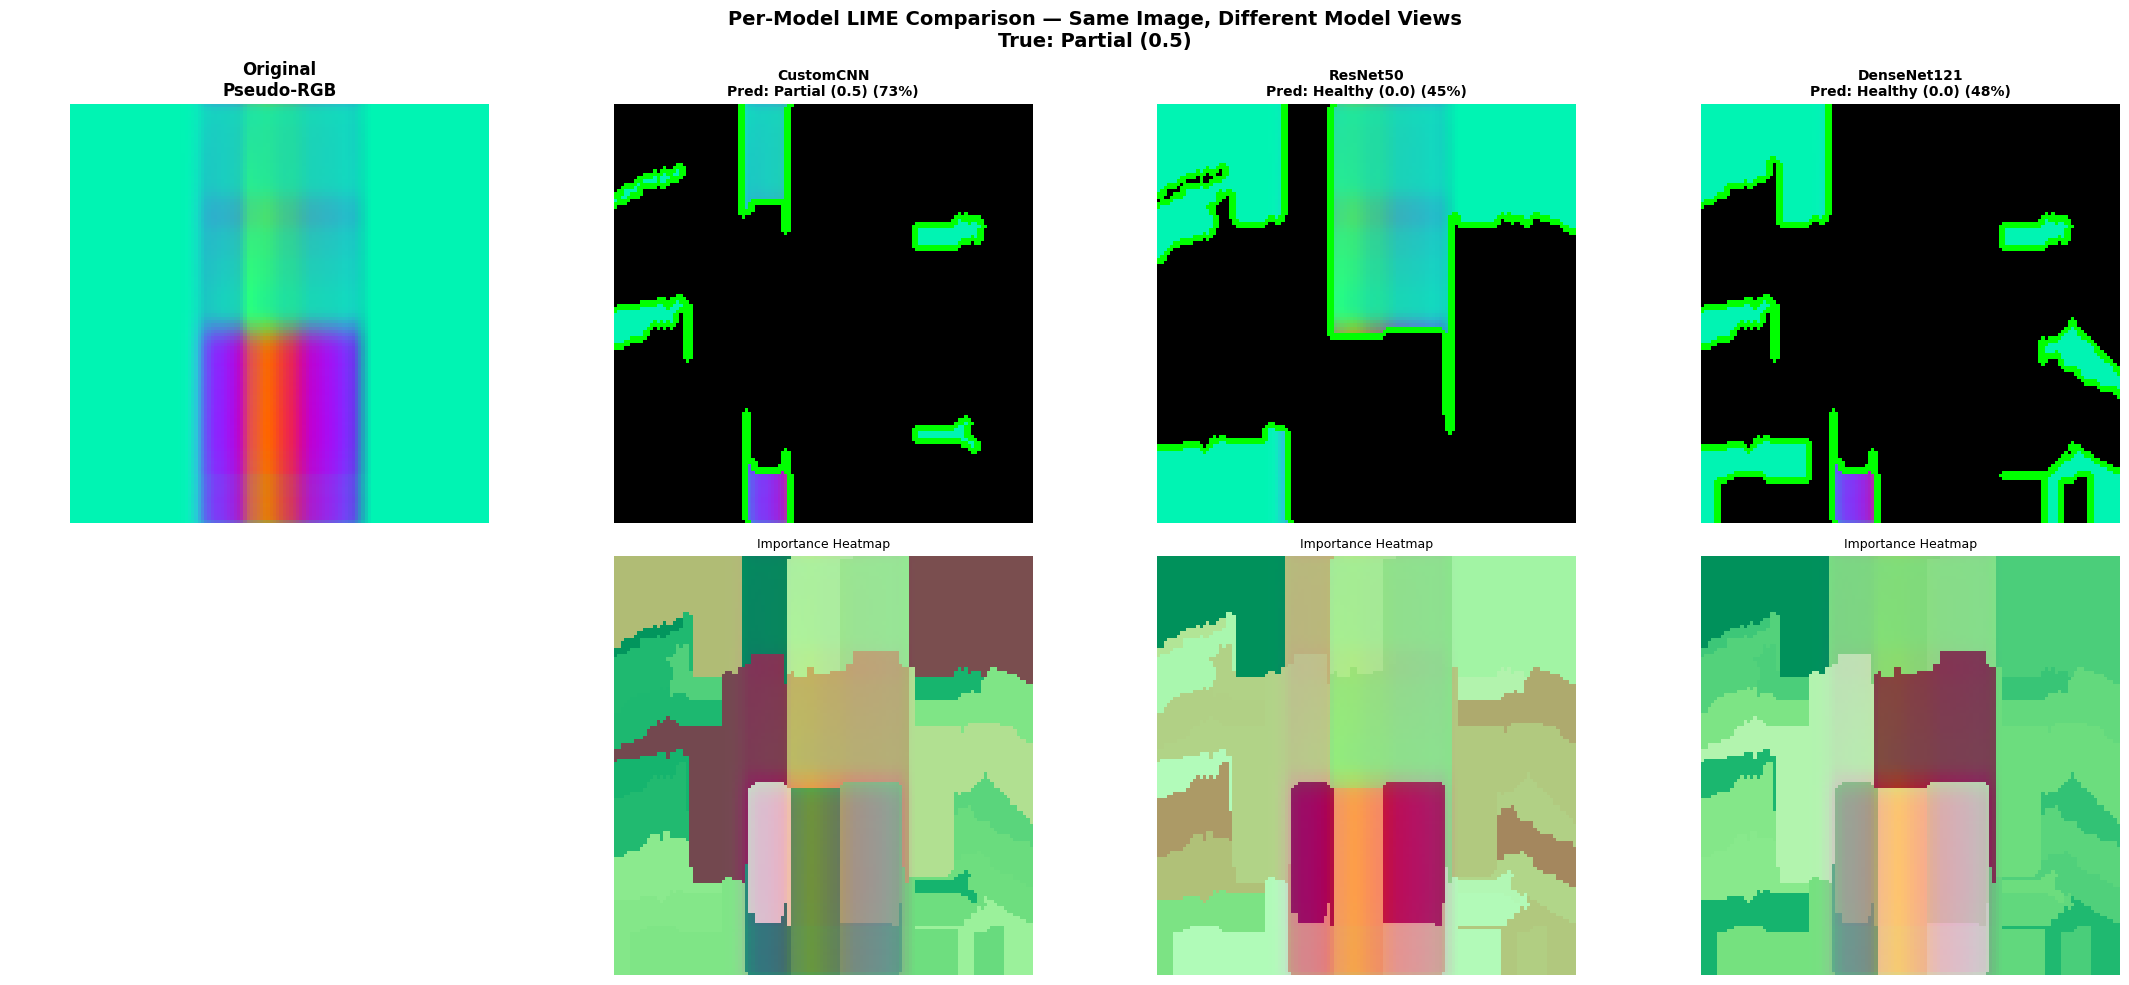

Saved: lime_per_model_comparison.png


In [11]:
# ─── Cell 8: Visualization 3 — Per-Model LIME Comparison ──────────────────────
COMPARE_INDEX = class_samples[1]   # Use Partial (0.5) sample — hardest class

sample_cmp   = X_test[COMPARE_INDEX]
rgb_cmp      = hsi_to_pseudoRGB(sample_cmp)
true_lbl_cmp = CLASS_NAMES[y_test_enc[COMPARE_INDEX]]

print(f'Per-model LIME for index {COMPARE_INDEX} | True: {true_lbl_cmp}')

fig, axes = plt.subplots(2, len(all_models) + 1, figsize=(22, 10))
fig.suptitle(
    f'Per-Model LIME Comparison — Same Image, Different Model Views\nTrue: {true_lbl_cmp}',
    fontsize=14, fontweight='bold'
)

axes[0, 0].imshow(rgb_cmp)
axes[0, 0].set_title('Original\nPseudo-RGB', fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for col, (model, mname) in enumerate(zip(all_models, model_names)):
    pseudo_orig = hsi_to_pseudoRGB(sample_cmp)

    def make_single_model_fn(m, orig_15ch):
        p_rgb = hsi_to_pseudoRGB(orig_15ch)
        def fn(imgs_3ch):
            N  = len(imgs_3ch)
            b  = np.zeros((N, IMG_H, IMG_W, N_BANDS), dtype=np.float32)
            for i, img in enumerate(imgs_3ch):
                diff       = np.abs(img.astype(np.float32) - p_rgb).mean(axis=-1)
                recon      = orig_15ch.copy()
                recon[diff > 0.08] = 0.0
                b[i]       = recon
            return m.predict(b, batch_size=32, verbose=0)
        return fn

    single_fn = make_single_model_fn(model, sample_cmp)
    single_pred = model.predict(sample_cmp[np.newaxis], verbose=0)[0]
    single_pidx = int(np.argmax(single_pred))
    single_conf = float(single_pred[single_pidx])

    print(f'  Running LIME for {mname} (pred: {CLASS_NAMES[single_pidx]}, {single_conf*100:.1f}%)...')
    exp_model = explainer.explain_instance(
        image=pseudo_orig, classifier_fn=single_fn,
        top_labels=N_CLASSES, hide_color=0,
        num_samples=600, batch_size=32
    )

    t, m_ = exp_model.get_image_and_mask(single_pidx, positive_only=True, num_features=8, hide_rest=True)
    axes[0, col+1].imshow(mark_boundaries(t, m_, color=(0, 1, 0), mode='thick'))
    axes[0, col+1].set_title(f'{mname}\nPred: {CLASS_NAMES[single_pidx]} ({single_conf*100:.0f}%)',
                              fontweight='bold', fontsize=10)
    axes[0, col+1].axis('off')

    dh = dict(exp_model.local_exp[single_pidx])
    hm = np.vectorize(dh.get)(exp_model.segments)
    axes[1, col+1].imshow(hm, cmap='RdYlGn')
    axes[1, col+1].imshow(rgb_cmp, alpha=0.3)
    axes[1, col+1].set_title('Importance Heatmap', fontsize=9)
    axes[1, col+1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lime_per_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lime_per_model_comparison.png')


Running LIME for dashboard...


  0%|          | 0/800 [00:00<?, ?it/s]

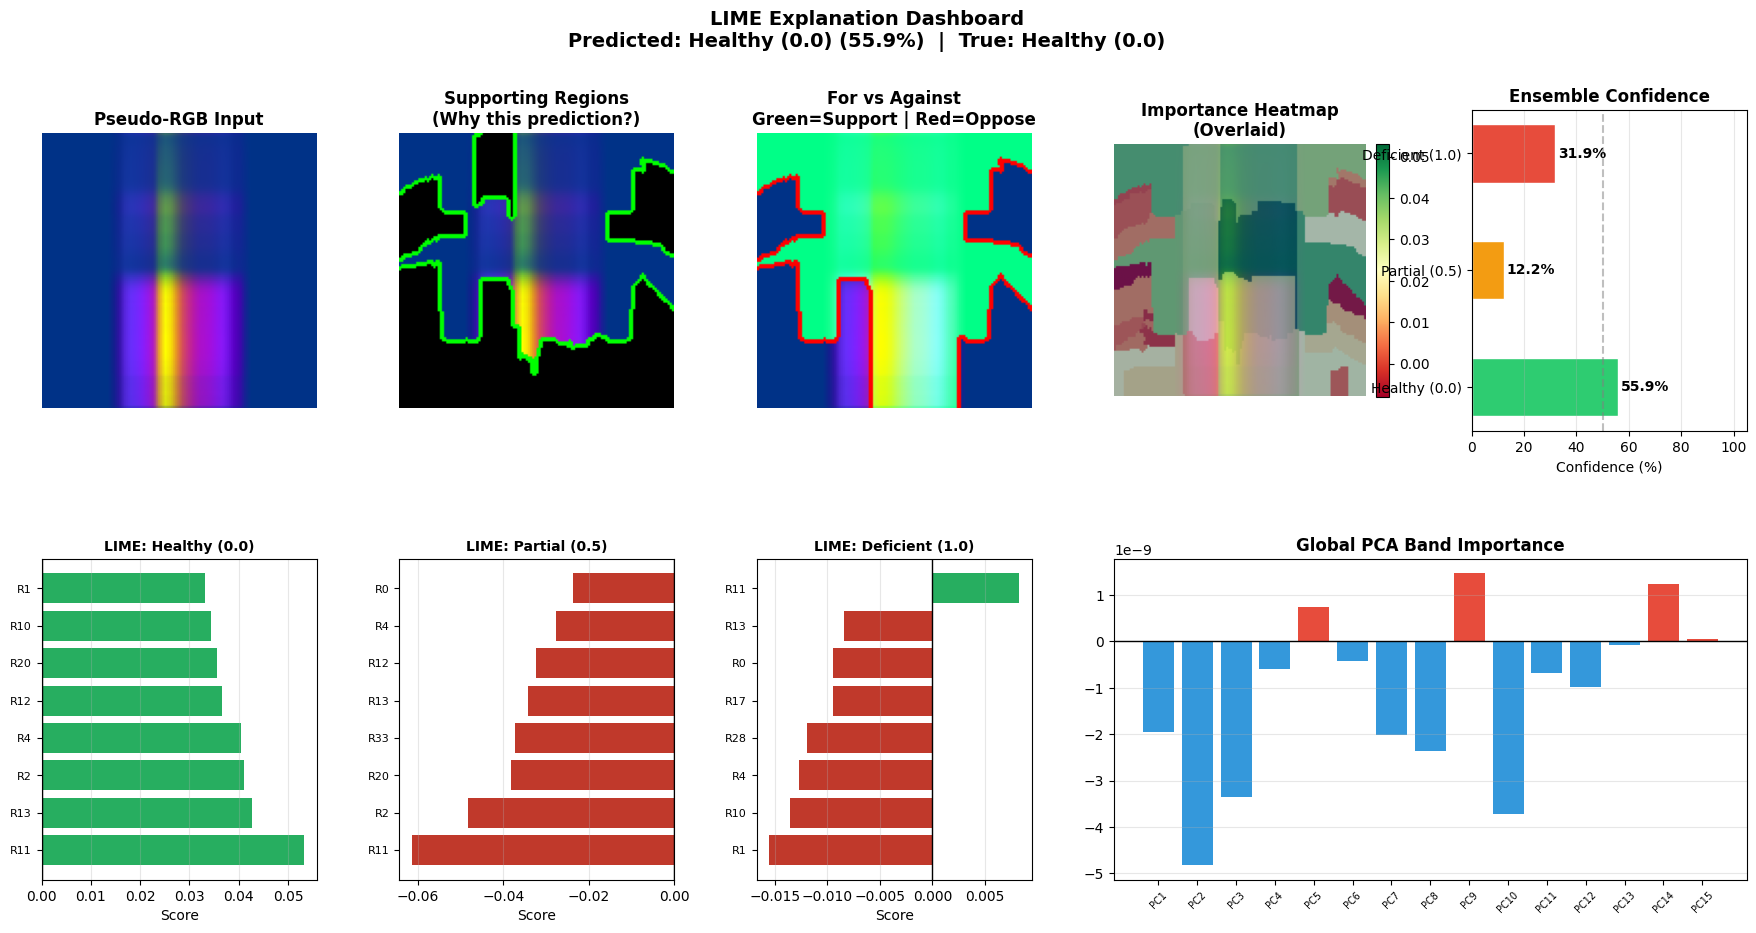

Saved: lime_dashboard.png


In [14]:
# ─── Cell 10: Visualization 5 — LIME Confidence Dashboard ─────────────────────
DEMO_INDEX = class_samples[0]   # Healthy sample

sample_d  = X_test[DEMO_INDEX]
rgb_d     = hsi_to_pseudoRGB(sample_d)
true_ld   = CLASS_NAMES[y_test_enc[DEMO_INDEX]]

probs_d, pidx_d, conf_d = predict_single(sample_d)
pred_ld = CLASS_NAMES[pidx_d]

lime_fn_d = make_lime_predict_fn(sample_d)
print('Running LIME for dashboard...')
exp_d = explainer.explain_instance(
    image=rgb_d, classifier_fn=lime_fn_d,
    top_labels=N_CLASSES, hide_color=0,
    num_samples=800, batch_size=32
)

fig = plt.figure(figsize=(22, 10))
gs  = gridspec.GridSpec(2, 5, figure=fig, wspace=0.3, hspace=0.4)
fig.suptitle(
    f'LIME Explanation Dashboard\n'
    f'Predicted: {pred_ld} ({conf_d*100:.1f}%)  |  True: {true_ld}',
    fontsize=14, fontweight='bold'
)

ax_orig = fig.add_subplot(gs[0, 0])
ax_orig.imshow(rgb_d)
ax_orig.set_title('Pseudo-RGB Input', fontweight='bold')
ax_orig.axis('off')

ax_sup = fig.add_subplot(gs[0, 1])
ts, ms = exp_d.get_image_and_mask(pidx_d, positive_only=True, num_features=8, hide_rest=True)
ax_sup.imshow(mark_boundaries(ts, ms, color=(0,1,0), mode='thick'))
ax_sup.set_title('Supporting Regions\n(Why this prediction?)', fontweight='bold')
ax_sup.axis('off')

ax_all = fig.add_subplot(gs[0, 2])
ta, ma = exp_d.get_image_and_mask(pidx_d, positive_only=False, num_features=10, hide_rest=False)
ax_all.imshow(mark_boundaries(ta, ma, color=(1,0,0), mode='thick'))
ax_all.set_title('For vs Against\nGreen=Support | Red=Oppose', fontweight='bold')
ax_all.axis('off')

ax_hm = fig.add_subplot(gs[0, 3])
dh = dict(exp_d.local_exp[pidx_d])
hm = np.vectorize(dh.get)(exp_d.segments)
im = ax_hm.imshow(hm, cmap='RdYlGn')
ax_hm.imshow(rgb_d, alpha=0.35)
plt.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)
ax_hm.set_title('Importance Heatmap\n(Overlaid)', fontweight='bold')
ax_hm.axis('off')

ax_conf = fig.add_subplot(gs[0, 4])
ax_conf.barh(CLASS_NAMES, probs_d * 100, color=CLASS_COLORS, edgecolor='white', height=0.5)
ax_conf.axvline(50, color='gray', ls='--', alpha=0.5)
ax_conf.set_xlim(0, 105)
ax_conf.set_xlabel('Confidence (%)')
ax_conf.set_title('Ensemble Confidence', fontweight='bold')
for i, v in enumerate(probs_d):
    ax_conf.text(v*100 + 1, i, f'{v*100:.1f}%', va='center', fontweight='bold')
ax_conf.grid(axis='x', alpha=0.3)

for cls_col, cls_idx in enumerate(range(N_CLASSES)):
    ax_cls = fig.add_subplot(gs[1, cls_col])
    if cls_idx in exp_d.local_exp:
        vals_cls = exp_d.local_exp[cls_idx]
        vs_sorted = sorted(vals_cls, key=lambda x: abs(x[1]), reverse=True)[:8]
        fids, imps = zip(*vs_sorted)
        c_bars = ['#27ae60' if v > 0 else '#c0392b' for v in imps]
        ax_cls.barh(range(len(fids)), imps, color=c_bars)
        ax_cls.set_yticks(range(len(fids)))
        ax_cls.set_yticklabels([f'R{f}' for f in fids], fontsize=8)
        ax_cls.axvline(0, color='black', lw=1)
        ax_cls.grid(axis='x', alpha=0.3)
    ax_cls.set_title(f'LIME: {CLASS_NAMES[cls_idx]}', fontweight='bold', fontsize=10)
    ax_cls.set_xlabel('Score')

ax_band = fig.add_subplot(gs[1, 3:])
ax_band.bar(range(N_BANDS), mean_imp,
            color=['#e74c3c' if v > 0 else '#3498db' for v in mean_imp])
ax_band.set_xticks(range(N_BANDS))
ax_band.set_xticklabels([f'PC{i+1}' for i in range(N_BANDS)], fontsize=7, rotation=45)
ax_band.set_title('Global PCA Band Importance', fontweight='bold')
ax_band.axhline(0, color='black', lw=1); ax_band.grid(axis='y', alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, 'lime_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lime_dashboard.png')


In [ ]:
# ─── Cell 11: Save LIME Utils for Streamlit ───────────────────────────────────
lime_utils_code = '''
"""
lime_utils.py — LIME utilities for Hyperspectral Streamlit App
Place this in the same folder as app.py or in src/
"""
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

IMG_H, IMG_W, N_BANDS = 128, 128, 15


def hsi_to_pseudoRGB(hsi_15ch):
    rgb = hsi_15ch[:, :, :3].copy().astype(np.float32)
    for c in range(3):
        ch = rgb[:, :, c]
        mn, mx = ch.min(), ch.max()
        rgb[:, :, c] = (ch - mn) / (mx - mn) if mx > mn else 0.0
    return rgb


def make_lime_predict_fn(original_15ch, models_list, weights):
    pseudo_orig = hsi_to_pseudoRGB(original_15ch)
    def predict_fn(imgs_3ch):
        N = len(imgs_3ch)
        batch = np.zeros((N, IMG_H, IMG_W, N_BANDS), dtype=np.float32)
        for i, img in enumerate(imgs_3ch):
            diff = np.abs(img.astype(np.float32) - pseudo_orig).mean(axis=-1)
            recon = original_15ch.copy()
            recon[diff > 0.08] = 0.0
            batch[i] = recon
        preds = [m.predict(batch, batch_size=32, verbose=0) for m in models_list]
        return np.average(preds, axis=0, weights=weights)
    return predict_fn


def run_lime_explanation(hsi_15ch, models_list, weights, class_names,
                          pred_idx, num_samples=500):
    pseudo_rgb  = hsi_to_pseudoRGB(hsi_15ch)
    predict_fn  = make_lime_predict_fn(hsi_15ch, models_list, weights)
    explainer   = lime_image.LimeImageExplainer(random_state=42)
    explanation = explainer.explain_instance(
        image=pseudo_rgb, classifier_fn=predict_fn,
        top_labels=len(class_names), hide_color=0,
        num_samples=num_samples, batch_size=32
    )
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"LIME — Predicted: {class_names[pred_idx]}", fontsize=13, fontweight="bold")
    axes[0].imshow(pseudo_rgb); axes[0].set_title("Pseudo-RGB", fontweight="bold"); axes[0].axis("off")
    t, m = explanation.get_image_and_mask(pred_idx, positive_only=True, num_features=8, hide_rest=True)
    axes[1].imshow(mark_boundaries(t, m, color=(0, 1, 0), mode="thick"))
    axes[1].set_title("Supporting Regions", fontweight="bold"); axes[1].axis("off")
    t2, m2 = explanation.get_image_and_mask(pred_idx, positive_only=False, num_features=10, hide_rest=False)
    axes[2].imshow(mark_boundaries(t2, m2, color=(1, 0, 0), mode="thick"))
    axes[2].set_title("Green=For | Red=Against", fontweight="bold"); axes[2].axis("off")
    dh = dict(explanation.local_exp[pred_idx])
    heatmap = np.vectorize(dh.get)(explanation.segments)
    im = axes[3].imshow(heatmap, cmap="RdYlGn")
    axes[3].imshow(pseudo_rgb, alpha=0.35)
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    axes[3].set_title("Importance Heatmap", fontweight="bold"); axes[3].axis("off")
    plt.tight_layout()
    return fig, explanation, heatmap
'''

os.makedirs('../src', exist_ok=True)
with open('../src/lime_utils.py', 'w') as f:
    f.write(lime_utils_code.strip())

print('Saved: ../src/lime_utils.py')


In [ ]:
# ─── Cell 12: Summary ─────────────────────────────────────────────────────────
print('=' * 60)
print('LIME XAI Notebook Complete!')
print('=' * 60)
print()
print('Generated files:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath) // 1024
    print(f'  {fname:45s}  ({size} KB)')

print()
print('lime_utils.py saved to: ../src/lime_utils.py')
print('\nStreamlit app can now use:')
print('  from lime_utils import run_lime_explanation, hsi_to_pseudoRGB')
